<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Feature Engineering - Solution

---

### About
Explain what feature engineering is, why it is important, and how to do it.

### Learning Objectives
- Explain the reasons for applying feature engineering to the data when modeling.
- Identify the relevant methods to apply to categorical data.
- Understand how and when to group continuous data into bins.
- Explain the reasons to transform your continuous data when modeling.
- Create transformers with scikit-learn to develop a pipeline of transformations for your data.

### Notebook Guide
1. What is Feature Engineering?
2. Working with Categorical Data
     - Label Encoding
     - One-Hot Encoding
3. Binning Continuous Variables
4. Transforming Continuous Variables
5. Building Feature Engineering Pipelines
6. Conclusions and Takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# These are needed for the second part of the lesson (Transforming Continuous Variables and Pipelines)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

import warnings
warnings.filterwarnings('ignore')

# What is Feature Engineering?

Feature engineering is the process of transforming raw data into features that better represent the underlying problem to the predictive models, resulting in improved model accuracy on unseen data.

Think of it as preparing your ingredients before cooking - you wouldn't throw whole vegetables into a soup without chopping them first!

## The Data

We'll use a housing data set that contains various features about houses and their sale prices. This is perfect for demonstrating different feature engineering techniques.

In [2]:
# Load the housing data
# For this demo, we'll create a synthetic data set that mimics real housing data
np.random.seed(42)

n_samples = 1000

# Create synthetic housing data
housing_data = {
    'sqft': np.random.normal(2000, 500, n_samples),
    'bedrooms': np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.2, 0.4, 0.25, 0.05]),
    'bathrooms': np.random.choice([1, 1.5, 2, 2.5, 3, 3.5, 4], n_samples, p=[0.15, 0.1, 0.3, 0.15, 0.2, 0.05, 0.05]),
    'neighborhood': np.random.choice(['Downtown', 'Suburb', 'Rural', 'Waterfront'], n_samples, p=[0.3, 0.5, 0.15, 0.05]),
    'year_built': np.random.randint(1950, 2023, n_samples),
    'garage': np.random.choice(['None', 'Attached', 'Detached'], n_samples, p=[0.2, 0.6, 0.2]),
    'condition': np.random.choice(['Poor', 'Fair', 'Good', 'Excellent'], n_samples, p=[0.1, 0.2, 0.5, 0.2]),
    'income_area': np.random.exponential(50000, n_samples) + 30000
}

housing = pd.DataFrame(housing_data)

# Make sqft positive
housing['sqft'] = np.abs(housing['sqft'])

# Create a realistic price based on features
price_base = (housing['sqft'] * 150 + 
              housing['bedrooms'] * 10000 + 
              housing['bathrooms'] * 8000 + 
              (2023 - housing['year_built']) * -500 +
              housing['income_area'] * 2)

# Add neighborhood effects
neighborhood_effects = {'Downtown': 50000, 'Waterfront': 80000, 'Suburb': 20000, 'Rural': -10000}
for neighborhood, effect in neighborhood_effects.items():
    price_base += (housing['neighborhood'] == neighborhood) * effect

# Add some noise
housing['price'] = price_base + np.random.normal(0, 20000, n_samples)
housing['price'] = np.abs(housing['price'])  # Ensure positive prices

In [3]:
housing.head()

,sqft,bedrooms,bathrooms,neighborhood,year_built,garage,condition,income_area,price
0,2248.357077,2,1.5,Suburb,1965,Attached,Good,112445.149004,599867.724286
1,1930.867849,2,1.0,Downtown,1996,None,Fair,52033.155108,434201.513289
2,2323.844269,3,1.0,Suburb,2008,Attached,Excellent,35320.702501,462645.316943
3,2761.514928,4,2.0,Rural,1980,Attached,Poor,193361.617481,819613.197210
4,1882.923313,1,3.0,Suburb,1953,None,Excellent,82864.211302,453750.701457


In [4]:
housing.describe()

,sqft,bedrooms,bathrooms,year_built,income_area,price
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1.000000e+03
mean,2009.666028,2.956000,2.24350,1985.53000,81880.912564,5.213387e+05
std,489.607969,1.035923,0.82075,20.98937,49981.827957,1.314391e+05
min,379.366330,1.000000,1.00000,1950.00000,30270.658349,2.122707e+05
25%,1676.204847,2.000000,2.00000,1967.00000,45686.441136,4.335291e+05
50%,2012.650306,3.000000,2.00000,1986.00000,67216.199353,5.034150e+05
75%,2323.971938,4.000000,3.00000,2004.00000,103837.885844,5.879252e+05
max,3926.365745,5.000000,4.00000,2022.00000,442986.711935,1.314976e+06


Let's take a quick look at our data types and see what we're working with:

In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sqft          1000 non-null   float64
 1   bedrooms      1000 non-null   int32  
 2   bathrooms     1000 non-null   float64
 3   neighborhood  1000 non-null   object 
 4   year_built    1000 non-null   int32  
 5   garage        1000 non-null   object 
 6   condition     1000 non-null   object 
 7   income_area   1000 non-null   float64
 8   price         1000 non-null   float64
dtypes: float64(4), int32(2), object(3)
memory usage: 62.6+ KB


---

# Working with Categorical Data

Categorical variables are variables that take on a limited number of distinct values. Most machine learning algorithms can't handle categorical data directly - they need numbers!

## Identifying Categorical Variables

Let's identify the unique values in each column for all features in our data set that are categorical:

In [6]:
# Look at unique values in categorical columns
categorical_cols = ['neighborhood', 'garage', 'condition']

for col in categorical_cols:
    print(f"{col}: {housing[col].unique()}")

neighborhood: ['Suburb' 'Downtown' 'Rural' 'Waterfront']
garage: ['Attached' 'None' 'Detached']
condition: ['Good' 'Fair' 'Excellent' 'Poor']


## Label Encoding

Label encoding converts categorical labels into numbers. This works well for ordinal data (where order matters).

In [7]:
# Let's label encode the 'condition' variable since it has a natural order
# le = LabelEncoder()

# Create a mapping for condition to make it ordinal
condition_mapping = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
housing['condition_encoded'] = housing['condition'].map(condition_mapping)

print("Original condition:")
print(housing['condition'].value_counts())
print("\nEncoded condition:")
print(housing['condition_encoded'].value_counts())

Original condition:
condition
Good         521
Excellent    191
Fair         182
Poor         106
Name: count, dtype: int64

Encoded condition:
condition_encoded
2    521
3    191
1    182
0    106
Name: count, dtype: int64


In [8]:
# Check the relationship between encoded condition and price
housing.groupby('condition_encoded')['price'].mean()

condition_encoded
0    506485.218644
1    531140.772671
2    514371.921697
3    539245.377868
Name: price, dtype: float64

<details><summary>Why is label encoding appropriate for 'condition' but not for 'neighborhood'?</summary>
Condition has a natural order (Poor < Fair < Good < Excellent), while neighborhood categories don't have a meaningful order.
</details>

## One-Hot Encoding

One-hot encoding creates binary columns for each category. This is better for nominal data (no natural order).

In [9]:
# One-hot encode the neighborhood variable
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform
neighborhood_encoded = ohe.fit_transform(housing[['neighborhood']])

# Get feature names
feature_names = ohe.get_feature_names_out(['neighborhood'])

# Create DataFrame
neighborhood_df = pd.DataFrame(neighborhood_encoded, columns=feature_names)
print(neighborhood_df.head())

   neighborhood_Rural  neighborhood_Suburb  neighborhood_Waterfront
0                 0.0                  1.0                      0.0
1                 0.0                  0.0                      0.0
2                 0.0                  1.0                      0.0
3                 1.0                  0.0                      0.0
4                 0.0                  1.0                      0.0


In [10]:
# Combine with original data
housing_encoded = pd.concat([housing, neighborhood_df], axis=1)
housing_encoded.head()

,sqft,bedrooms,bathrooms,neighborhood,year_built,garage,condition,income_area,price,condition_encoded,neighborhood_Rural,neighborhood_Suburb,neighborhood_Waterfront
0,2248.357077,2,1.5,Suburb,1965,Attached,Good,112445.149004,599867.724286,2,0.0,1.0,0.0
1,1930.867849,2,1.0,Downtown,1996,None,Fair,52033.155108,434201.513289,1,0.0,0.0,0.0
2,2323.844269,3,1.0,Suburb,2008,Attached,Excellent,35320.702501,462645.316943,3,0.0,1.0,0.0
3,2761.514928,4,2.0,Rural,1980,Attached,Poor,193361.617481,819613.197210,0,1.0,0.0,0.0
4,1882.923313,1,3.0,Suburb,1953,None,Excellent,82864.211302,453750.701457,3,0.0,1.0,0.0


## Using `pandas` for Quick Encoding

`pandas` provides convenient methods for encoding:

In [11]:
# Use pandas get_dummies for one-hot encoding
housing_dummies = pd.get_dummies(housing, columns=['neighborhood', 'garage'], drop_first=True)
print(f"Original shape: {housing.shape}")
print(f"After dummies: {housing_dummies.shape}")
print(f"\nNew columns: {housing_dummies.columns.tolist()}")

Original shape: (1000, 10)
After dummies: (1000, 13)

New columns: ['sqft', 'bedrooms', 'bathrooms', 'year_built', 'condition', 'income_area', 'price', 'condition_encoded', 'neighborhood_Rural', 'neighborhood_Suburb', 'neighborhood_Waterfront', 'garage_Detached', 'garage_None']


---

#### To the slides!

---


# Binning Continuous Variables

Sometimes it's useful to convert continuous variables into categorical bins. This can help capture non-linear relationships and make models more interpretable.

## When to Bin Continuous Variables

- When you suspect non-linear relationships
- To reduce the impact of outliers
- To make model interpretations easier
- When domain knowledge suggests natural breakpoints

## Manual Binning with `pandas.cut()`

Let's bin the house `age` into categories:

In [12]:
# Create an age variable first
housing['age'] = datetime.now().year - housing['year_built']
print(f"Age range: {housing['age'].min()} to {housing['age'].max()}")
print(f"Age distribution:")
print(housing['age'].describe())

Age range: 4 to 76
Age distribution:
count    1000.00000
mean       40.47000
std        20.98937
min         4.00000
25%        22.00000
50%        40.00000
75%        59.00000
max        76.00000
Name: age, dtype: float64


Age category distribution:
age_category
Very Old    383
Old         251
Moderate    143
New         132
Very New     91
Name: count, dtype: int64


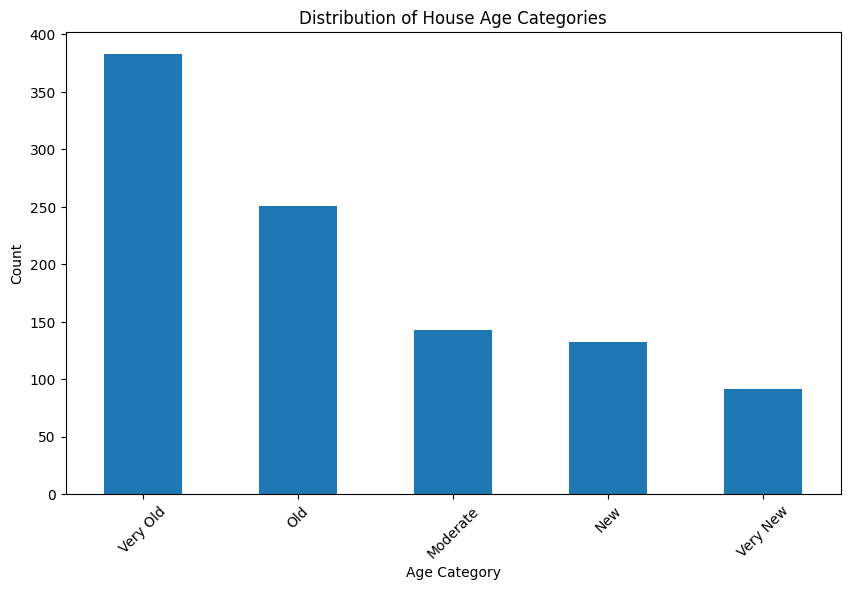

In [47]:
# Create age bins
age_bins = [0, 10, 20, 30, 50, 100]
age_labels = ['Very New', 'New', 'Moderate', 'Old', 'Very Old']

housing['age_category'] = pd.cut(housing['age'], bins=age_bins, labels=age_labels, include_lowest=True)

print("Age category distribution:")
print(f"{housing['age_category'].value_counts()}")

# Plot the distribution
plt.figure(figsize=(10, 6))
housing['age_category'].value_counts().plot(kind='bar')
plt.title('Distribution of House Age Categories')
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show();

In [14]:
# Check price by age category
price_by_age = housing.groupby('age_category')['price'].mean()
print("Average price by age category:")
print(price_by_age)

Average price by age category:
age_category
Very New    532012.529374
New         531165.925545
Moderate    522659.709046
Old         513302.310285
Very Old    520189.116343
Name: price, dtype: float64


## Equal-Frequency (quantile-based) Binning with `pandas.qcut()`

Sometimes we want equal-sized bins rather than equal-width bins:

In [ ]:
# Create income quartiles
housing['income_quartile'] = pd.qcut(housing['income_area'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print("Income quartile distribution:")
print(housing['income_quartile'].value_counts())

# Check the actual income ranges for each quartile
print("\nIncome ranges by quartile:")
print(housing.groupby('income_quartile')['income_area'].agg(['min', 'max', 'mean']))

Income quartile distribution:
income_quartile
Q1    250
Q2    250
Q3    250
Q4    250
Name: count, dtype: int64

Income ranges by quartile:
                           min            max           mean
income_quartile                                             
Q1                30270.658349   45670.663507   37307.304991
Q2                45691.700345   66983.716560   55336.260030
Q3                67448.682147  103826.213103   83883.614923
Q4               103872.904064  442986.711935  150996.470311


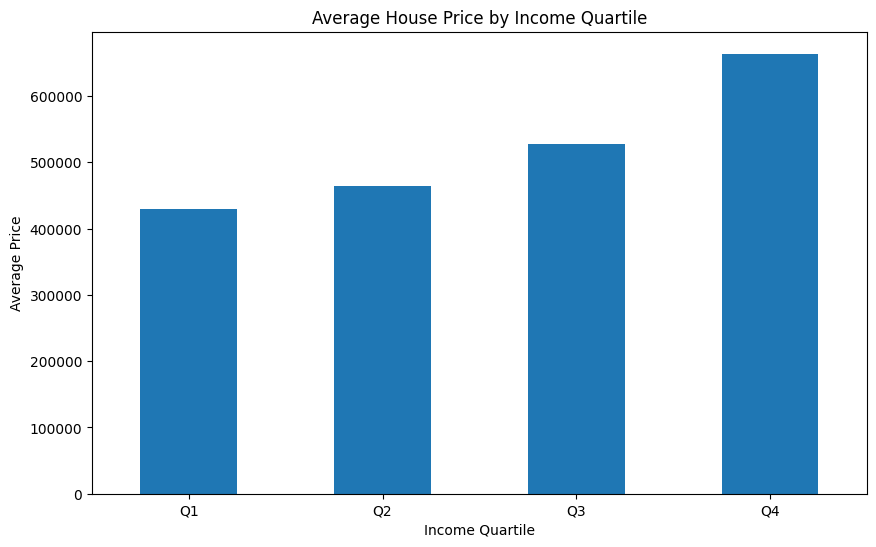

In [16]:
# Plot income vs price by quartile
plt.figure(figsize=(10, 6))
housing.groupby('income_quartile')['price'].mean().plot(kind='bar')
plt.title('Average House Price by Income Quartile')
plt.xlabel('Income Quartile')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show();

## An alternative way to do it: use `sklearn`'s `KBinsDiscretizer`

`scikit-learn` provides a more flexible binning tool:

In [17]:
# Use KBinsDiscretizer on square footage
binned = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')

# Fit and transform
sqft_binned = binned.fit_transform(housing[['sqft']])

# Add to housing dataframe
housing['sqft_binned'] = sqft_binned

print("Square footage bins:")
print(housing['sqft_binned'].value_counts().sort_index())

# Check the bin edges
print("\nBin edges:")
print(binned.bin_edges_[0])

Square footage bins:
sqft_binned
0.0    200
1.0    200
2.0    200
3.0    200
4.0    200
Name: count, dtype: int64

Bin edges:
[ 379.36632997 1597.35611136 1879.609636   2124.4010675  2406.75671334
 3926.36574533]


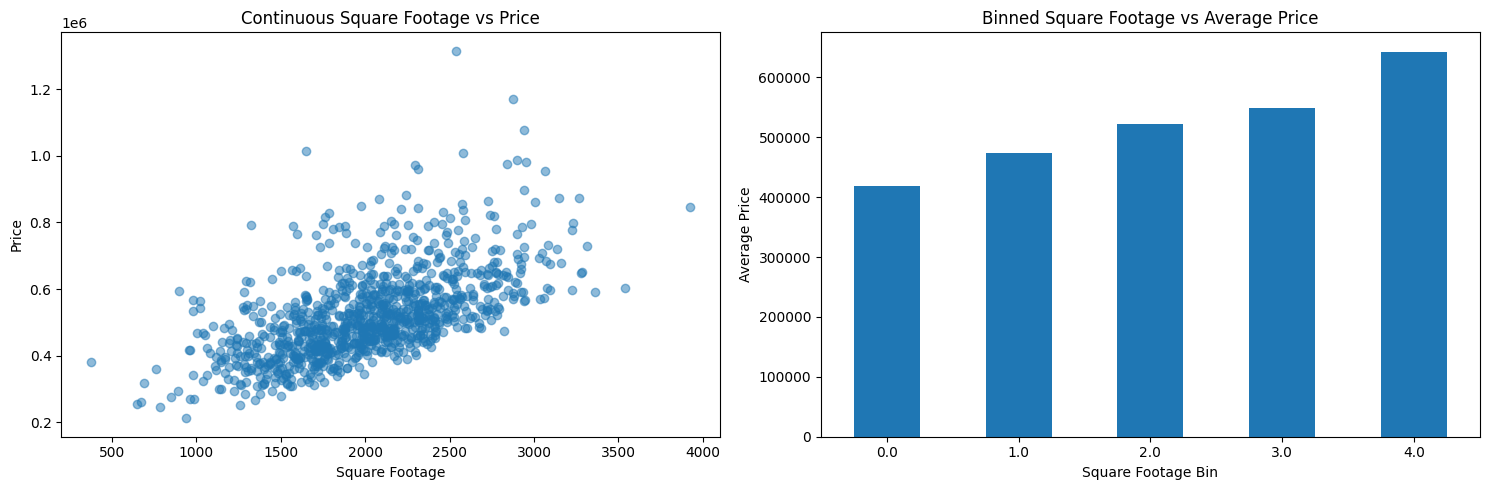

In [18]:
# Compare binned vs continuous sqft relationship with price
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Continuous relationship
ax1.scatter(housing['sqft'], housing['price'], alpha=0.5)
ax1.set_xlabel('Square Footage')
ax1.set_ylabel('Price')
ax1.set_title('Continuous Square Footage vs Price')

# Binned relationship
housing.groupby('sqft_binned')['price'].mean().plot(kind='bar', ax=ax2)
ax2.set_xlabel('Square Footage Bin')
ax2.set_ylabel('Average Price')
ax2.set_title('Binned Square Footage vs Average Price')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show();

---

#### To the slides!

---

# Transforming Continuous Variables

Many machine learning algorithms work better when features are on similar scales or follow certain distributions.

## Why Transform?

1. **Scale differences**: Some features might be in thousands, others in decimals
2. **Distribution shape**: Many algorithms assume normal distributions
3. **Algorithm requirements**: Some algorithms are sensitive to scale (e.g., KNN, SVM)
4. **Convergence**: Neural networks often train faster with scaled inputs

## Visualizing Our Continuous Variables

Let's look at the distributions first:

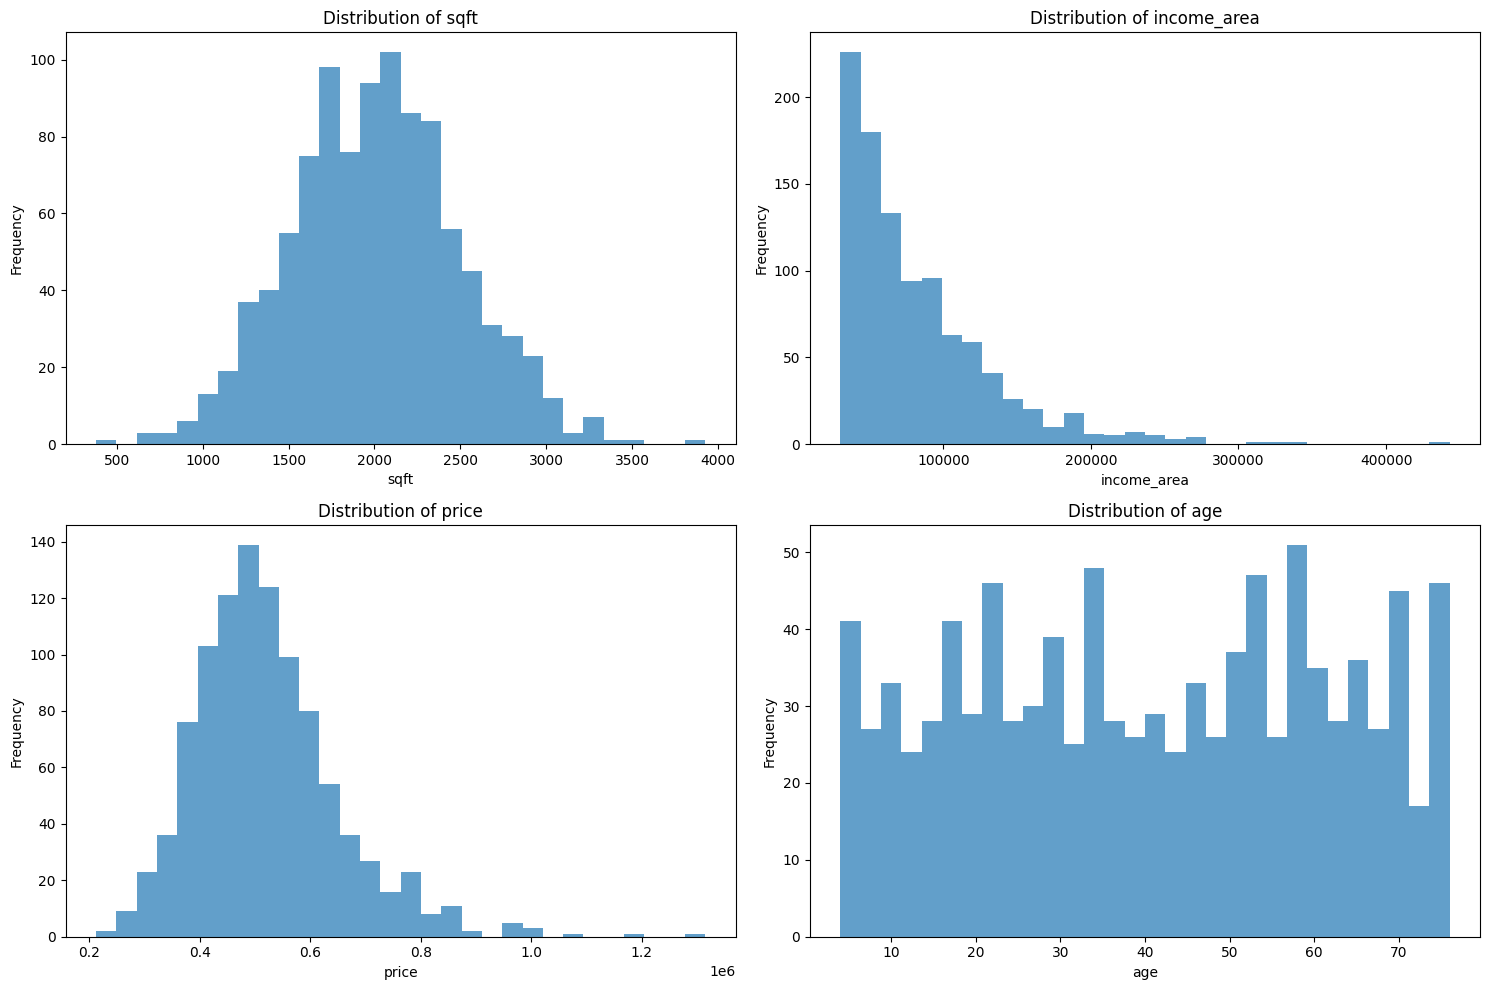

In [19]:
# Plot distributions of continuous variables
continuous_vars = ['sqft', 'income_area', 'price', 'age']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(continuous_vars):
    axes[i].hist(housing[var], bins=30, alpha=0.7)
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show();

## Scaling Transformations

### StandardScaler (Z-score normalization)
Transforms data to have mean=0 and std=1

In [20]:
# Apply StandardScaler to sqft
scaler = StandardScaler()

sqft_scaled = scaler.fit_transform(housing[['sqft']])

print("Original sqft stats:")
print(f"Mean: {housing['sqft'].mean():.2f}")
print(f"Std: {housing['sqft'].std():.2f}")

print("\nScaled sqft stats:")
print(f"Mean: {sqft_scaled.mean():.2f}")
print(f"Std: {sqft_scaled.std():.2f}")

# Add to dataframe
housing['sqft_standardized'] = sqft_scaled

Original sqft stats:
Mean: 2009.67
Std: 489.61

Scaled sqft stats:
Mean: 0.00
Std: 1.00


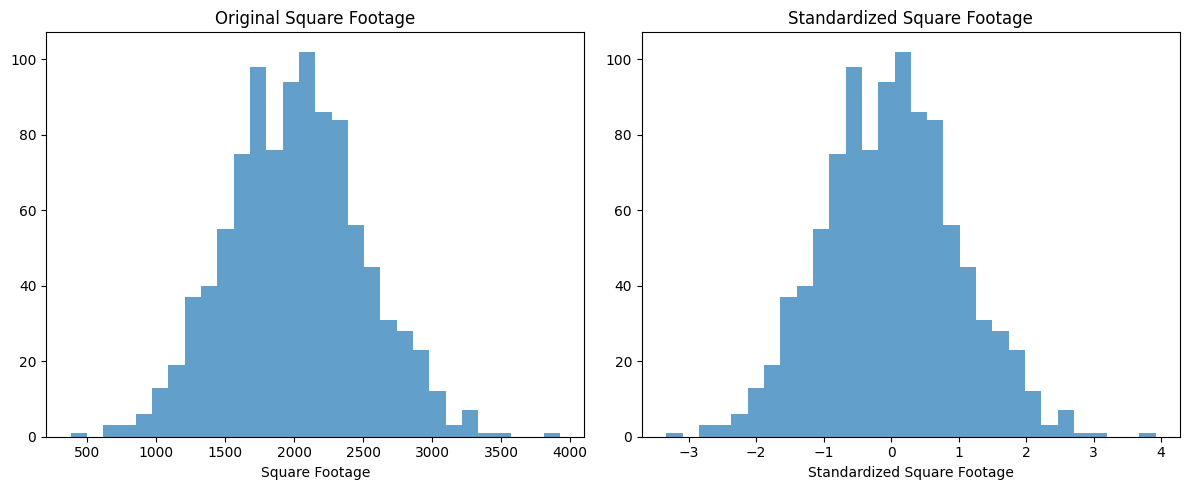

In [21]:
# Plot before and after scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(housing['sqft'], bins=30, alpha=0.7)
ax1.set_title('Original Square Footage')
ax1.set_xlabel('Square Footage')

ax2.hist(housing['sqft_standardized'], bins=30, alpha=0.7)
ax2.set_title('Standardized Square Footage')
ax2.set_xlabel('Standardized Square Footage')

plt.tight_layout()
plt.show();

### MinMaxScaler
Scales data to a fixed range (usually 0-1)

In [22]:
# Apply MinMaxScaler to income_area
minmax_scaler = MinMaxScaler()

income_scaled = minmax_scaler.fit_transform(housing[['income_area']])

print("Original income_area stats:")
print(f"Min: {housing['income_area'].min():.2f}")
print(f"Max: {housing['income_area'].max():.2f}")

print("\nScaled income_area stats:")
print(f"Min: {income_scaled.min():.2f}")
print(f"Max: {income_scaled.max():.2f}")

# Add to dataframe
housing['income_area_scaled'] = income_scaled

Original income_area stats:
Min: 30270.66
Max: 442986.71

Scaled income_area stats:
Min: 0.00
Max: 1.00


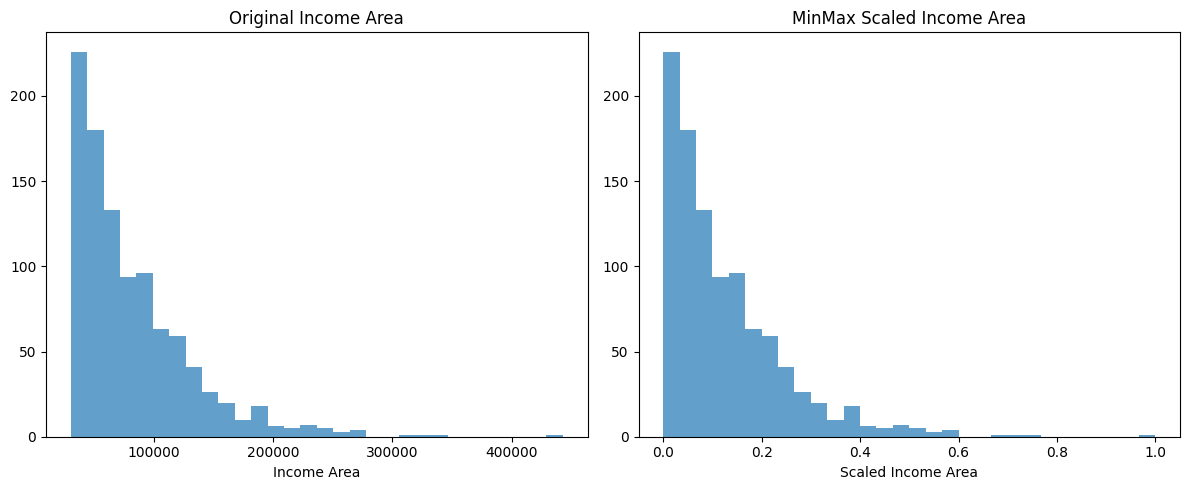

In [23]:
# Plot before and after MinMax scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(housing['income_area'], bins=30, alpha=0.7)
ax1.set_title('Original Income Area')
ax1.set_xlabel('Income Area')

ax2.hist(housing['income_area_scaled'], bins=30, alpha=0.7)
ax2.set_title('MinMax Scaled Income Area')
ax2.set_xlabel('Scaled Income Area')

plt.tight_layout()
plt.show();

## Distribution Transformations

### Log Transformation
Good for right-skewed data

In [24]:
# Apply log transformation to income_area (which is right-skewed)
housing['income_area_log'] = np.log(housing['income_area'])

print("Original income_area skewness:", housing['income_area'].skew())
print("Log-transformed income_area skewness:", housing['income_area_log'].skew())

Original income_area skewness: 1.8856514760071819
Log-transformed income_area skewness: 0.4176845017092041


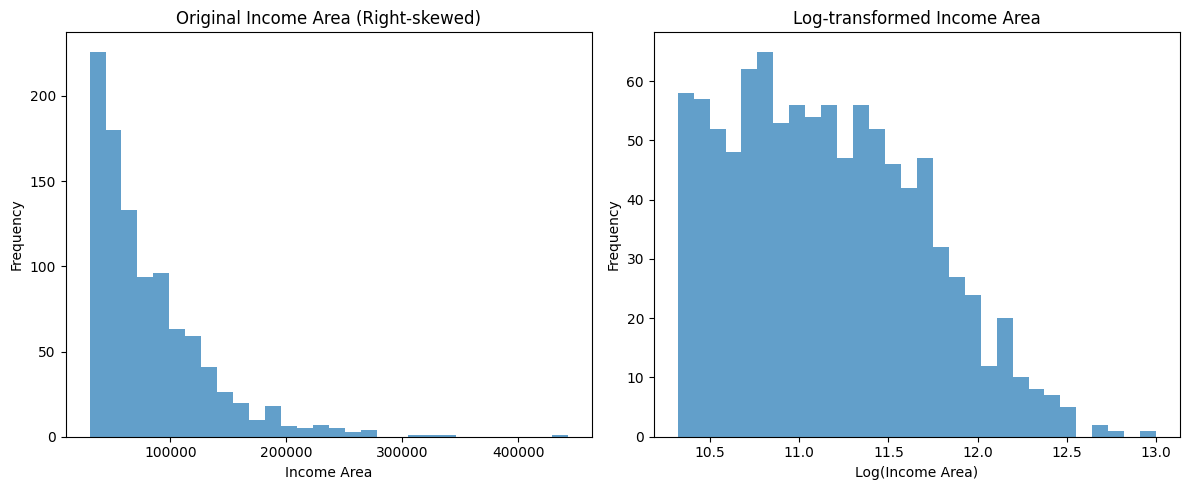

In [25]:
# Plot before and after log transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(housing['income_area'], bins=30, alpha=0.7)
ax1.set_title('Original Income Area (Right-skewed)')
ax1.set_xlabel('Income Area')
ax1.set_ylabel('Frequency')

ax2.hist(housing['income_area_log'], bins=30, alpha=0.7)
ax2.set_title('Log-transformed Income Area')
ax2.set_xlabel('Log(Income Area)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show();

### `PowerTransformer` (Box-Cox and Yeo-Johnson)
Automatically finds the best power transformation

In [26]:
# Use PowerTransformer on income_area
power_transformer = PowerTransformer(method='yeo-johnson')

income_power = power_transformer.fit_transform(housing[['income_area']])

print("Original income_area skewness:", housing['income_area'].skew())
print("Power-transformed income_area skewness:", pd.Series(income_power.flatten()).skew())

# Add to dataframe
housing['income_area_power'] = income_power

Original income_area skewness: 1.8856514760071819
Power-transformed income_area skewness: 0.06027229415616066


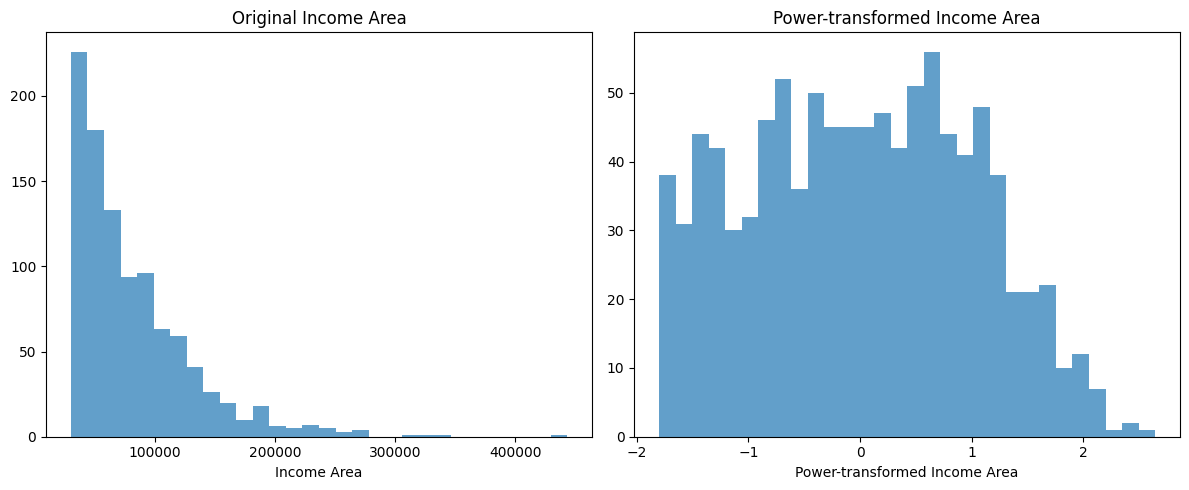

In [27]:
# Plot before and after power transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(housing['income_area'], bins=30, alpha=0.7)
ax1.set_title('Original Income Area')
ax1.set_xlabel('Income Area')

ax2.hist(housing['income_area_power'], bins=30, alpha=0.7)
ax2.set_title('Power-transformed Income Area')
ax2.set_xlabel('Power-transformed Income Area')

plt.tight_layout()
plt.show();

### `QuantileTransformer`
Maps to a uniform or normal distribution

In [28]:
# Use QuantileTransformer
quantile_transformer = QuantileTransformer(output_distribution='normal')

income_quantile = quantile_transformer.fit_transform(housing[['income_area']])

print("Original income_area skewness:", housing['income_area'].skew())
print("Quantile-transformed income_area skewness:", pd.Series(income_quantile.flatten()).skew())

# Add to dataframe
housing['income_area_quantile'] = income_quantile

Original income_area skewness: 1.8856514760071819
Quantile-transformed income_area skewness: 7.2040646789411705e-12


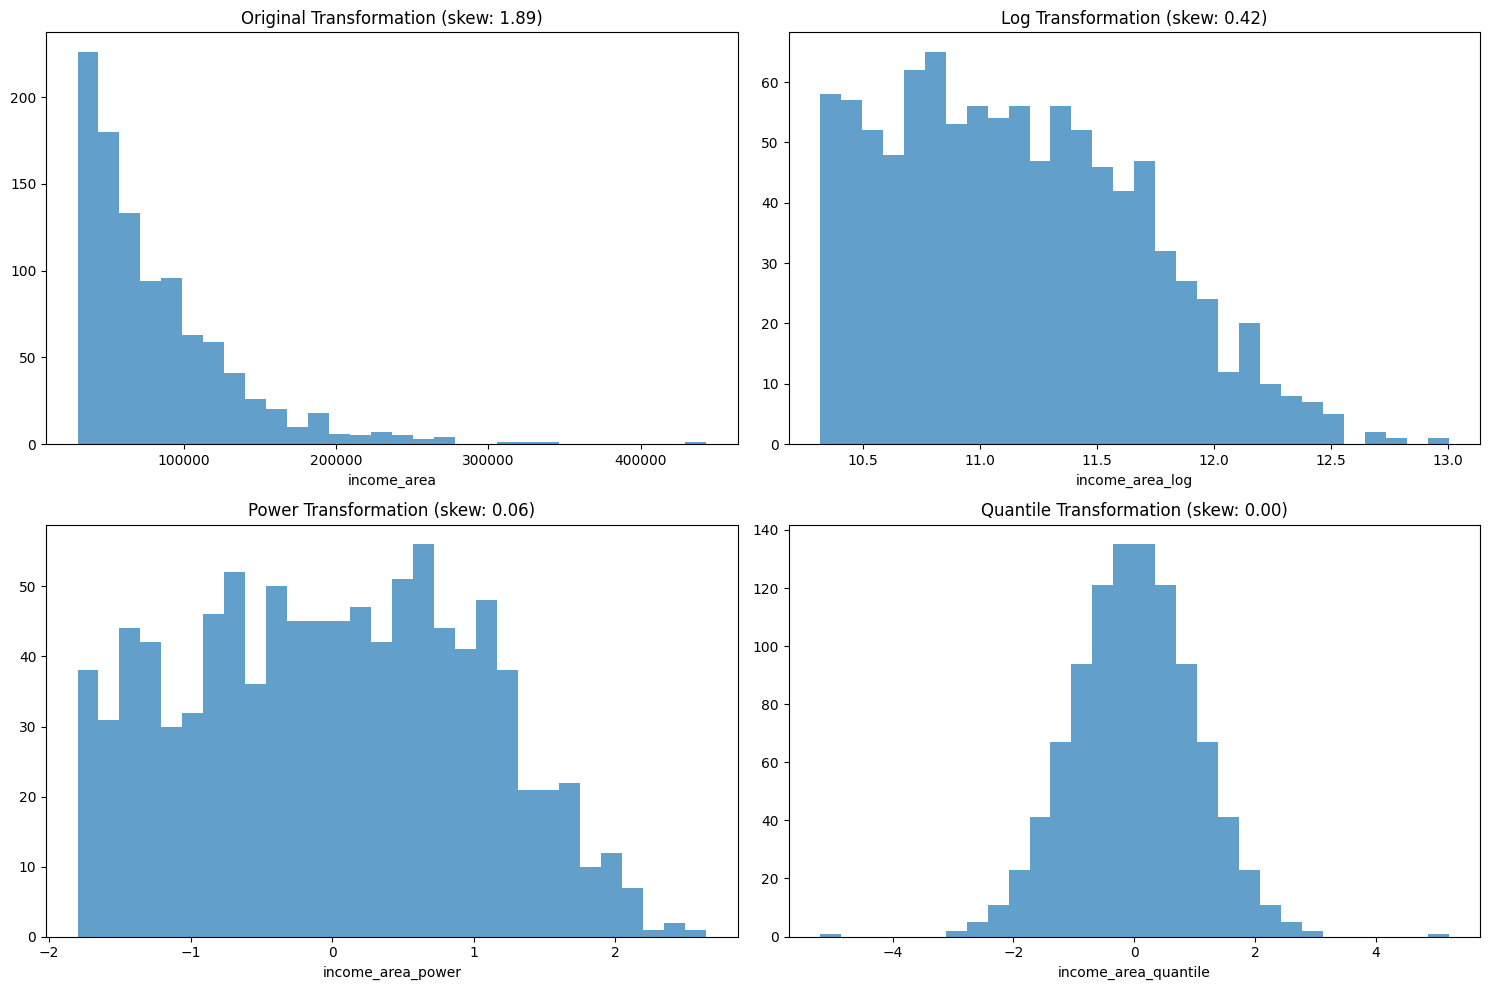

In [29]:
# Compare all transformations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

transformations = [
    ('Original', 'income_area'),
    ('Log', 'income_area_log'),
    ('Power', 'income_area_power'),
    ('Quantile', 'income_area_quantile')
]

for i, (name, col) in enumerate(transformations):
    axes[i].hist(housing[col], bins=30, alpha=0.7)
    axes[i].set_title(f'{name} Transformation')
    axes[i].set_xlabel(col)
    
    # Add skewness to title
    skew = housing[col].skew()
    axes[i].set_title(f'{name} Transformation (skew: {skew:.2f})')

plt.tight_layout()
plt.show();

---

#### To the slides!

---

# Building Feature Engineering Pipelines

In real projects, you'll want to apply multiple transformations systematically. Pipelines help us do this cleanly and avoid data leakage.

## Why Use Pipelines?

1. **Prevents data leakage**: Transformations are fit only on training data
2. **Reproducibility**: Same transformations applied consistently
3. **Cleaner code**: All preprocessing in one place
4. **Easy deployment**: Transform new data the same way

## Setting up Our Data

First, let's prepare our features and target:

In [30]:
# Define our feature columns and target
feature_cols = ['sqft', 'bedrooms', 'bathrooms', 'neighborhood', 'garage', 'condition', 'income_area']
X = housing[feature_cols].copy()
y = housing['price'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Feature matrix shape: (1000, 7)
Target vector shape: (1000,)

Feature columns: ['sqft', 'bedrooms', 'bathrooms', 'neighborhood', 'garage', 'condition', 'income_area']


In [31]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (800, 7)
Test set shape: (200, 7)


## Creating Column-Specific Transformers

Different columns need different transformations. We can handle this with `ColumnTransformer`:

In [32]:
# Define which columns are numeric and which are categorical
numeric_features = ['sqft', 'bedrooms', 'bathrooms', 'income_area']
categorical_features = ['neighborhood', 'garage', 'condition']

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numeric features: ['sqft', 'bedrooms', 'bathrooms', 'income_area']
Categorical features: ['neighborhood', 'garage', 'condition']


In [33]:
# Create transformers for each type
# Numeric transformer: scale the features
numeric_transformer = StandardScaler()

# Categorical transformer: one-hot encode
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False)

print("Transformers created!")

Transformers created!


In [34]:
# Combine transformers with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created!")

Preprocessor created!


## Creating a Complete Pipeline

Now let's combine our preprocessing with a model:

In [35]:
# Create a complete pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("Complete pipeline created!")
print(pipeline)

Complete pipeline created!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['sqft', 'bedrooms',
                                                   'bathrooms',
                                                   'income_area']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['neighborhood', 'garage',
                                                   'condition'])])),
                ('regressor', LinearRegression())])


In [36]:
# Fit the pipeline
pipeline.fit(X_train, y_train)
print("Pipeline fitted successfully!")

Pipeline fitted successfully!


## Evaluating Our Pipeline

Let's see how our feature engineering helps our model:

In [37]:
# Make predictions
y_pred = pipeline.predict(X_test)

print("Predictions made!")
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 actual values: {y_test.iloc[:5].values}")

Predictions made!
First 5 predictions: [512021.98564653 715030.19219789 381933.04709128 354423.66853308
 463829.83609913]
First 5 actual values: [518641.25615017 737772.43997753 407112.39596034 369207.9589997
 486477.8590253 ]


In [38]:
# Evaluate performance
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)

print("=== Pipeline Performance ===")
print(f"Mean Squared Error: ${mse:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: ${mae:,.2f}")

=== Pipeline Performance ===
Mean Squared Error: $535,236,684.63
Root Mean Squared Error: $23,135.18
R² Score: 0.964
Mean Absolute Error: $18,664.83


## Comparing with a Baseline

Let's compare this to a model without feature engineering:

In [39]:
# Create a simple baseline model with just numeric features
baseline_features = ['sqft', 'bedrooms', 'bathrooms']
X_train_baseline = X_train[baseline_features]
X_test_baseline = X_test[baseline_features]

# Simple linear regression without preprocessing
baseline_model = LinearRegression()
baseline_model.fit(X_train_baseline, y_train)

# Make predictions
y_pred_baseline = baseline_model.predict(X_test_baseline)

# Evaluate baseline
baseline_mse = metrics.mean_squared_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = metrics.r2_score(y_test, y_pred_baseline)
baseline_mae = metrics.mean_absolute_error(y_test, y_pred_baseline)

print("=== Baseline Performance ===")
print(f"Mean Squared Error: ${baseline_mse:,.2f}")
print(f"Root Mean Squared Error: ${baseline_rmse:,.2f}")
print(f"R² Score: {baseline_r2:.3f}")
print(f"Mean Absolute Error: ${baseline_mae:,.2f}")

=== Baseline Performance ===
Mean Squared Error: $8,097,738,800.14
Root Mean Squared Error: $89,987.44
R² Score: 0.452
Mean Absolute Error: $73,583.81


In [40]:
# Compare models
print("=== Model Comparison ===")
print(f"Pipeline R²: {r2:.3f}")
print(f"Baseline R²: {baseline_r2:.3f}")
print(f"Improvement: {((r2 - baseline_r2) / baseline_r2 * 100):+.1f}%")

print(f"\nPipeline RMSE: ${rmse:,.2f}")
print(f"Baseline RMSE: ${baseline_rmse:,.2f}")
print(f"RMSE reduction: ${baseline_rmse - rmse:,.2f}")

=== Model Comparison ===
Pipeline R²: 0.964
Baseline R²: 0.452
Improvement: +113.2%

Pipeline RMSE: $23,135.18
Baseline RMSE: $89,987.44
RMSE reduction: $66,852.25


<details><summary>Which model performs better and why?</summary>
The engineered model should perform better because:
1. We included categorical information that was ignored in the baseline
2. We properly scaled the features
3. We handled different data types appropriately
</details>

## Advanced Pipeline Features

### Custom Transformers

Sometimes you need custom transformations:

In [41]:
# Create a custom transformer that adds house age
class AgeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, current_year=2023):
        self.current_year = current_year
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Add age feature
        X = X.copy()
        X['age'] = self.current_year - X['year_built']
        return X

In [42]:
# Use the custom transformer in a pipeline
# First, add year_built to our features
feature_cols_with_year = feature_cols + ['year_built']
X_with_year = housing[feature_cols_with_year].copy()

# Split again
X_train_year, X_test_year, y_train_year, y_test_year = train_test_split(
    X_with_year, y, test_size=0.2, random_state=42
)

# Update numeric features to include age
numeric_features_with_age = numeric_features + ['age']

# Update preprocessor
preprocessor_with_age = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_with_age),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Create pipeline with custom transformer
custom_pipeline = Pipeline([
    ('age_transformer', AgeTransformer()),
    ('preprocessor', preprocessor_with_age),
    ('regressor', LinearRegression())
])

print("Custom pipeline created with age transformer!")

Custom pipeline created with age transformer!


### Handling Missing Data

Let's add some missing data and see how to handle it:

In [43]:
# Create some missing data for demonstration
X_with_missing = X_train.copy()

# Randomly set 5% of sqft values to NaN
np.random.seed(42)
missing_idx = np.random.choice(X_with_missing.index, size=int(0.05 * len(X_with_missing)), replace=False)
X_with_missing.loc[missing_idx, 'sqft'] = np.nan

print(f"Missing values created:")
print(X_with_missing.isnull().sum())

Missing values created:
sqft            40
bedrooms         0
bathrooms        0
neighborhood     0
garage           0
condition        0
income_area      0
dtype: int64


In [44]:
# Add imputation to our pipeline
# Numeric transformer with imputation
numeric_transformer_with_imputation = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer with imputation
categorical_transformer_with_imputation = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Updated preprocessor with imputation
preprocessor_with_imputation = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_with_imputation, numeric_features),
        ('cat', categorical_transformer_with_imputation, categorical_features)
    ]
)

# Pipeline with imputation
pipeline_with_imputation = Pipeline([
    ('preprocessor', preprocessor_with_imputation),
    ('regressor', LinearRegression())
])

# Fit on data with missing values
pipeline_with_imputation.fit(X_with_missing, y_train)

print("Pipeline with imputation fitted successfully!")

Pipeline with imputation fitted successfully!


# Conclusions and Takeaways

* **Feature engineering is crucial** for model performance - sometimes more important than the choice of algorithm!
* **Different data types need different treatments**: categorical vs. continuous variables require different encoding strategies.
* **Scaling matters** for many algorithms, especially distance-based ones.
* **Pipelines are essential** for reproducible, leak-free preprocessing.
* **Domain knowledge** often guides the best feature engineering choices.
* **Always validate** your transformations - plot before and after!

### Next Steps

Practice these techniques on your own data sets! Remember:
- Start simple and add complexity gradually
- Always split your data before engineering features
- Document your transformations for reproducibility
- Experiment with different approaches and measure their impact